In [4]:
#requirements:install libraries in terminal using：
# pip install -r requirements.txt
from utils.DataCleaning import process_sort, convert_text_to_score, merge_datasets
import matplotlib.pyplot as plt
from utils.VAR import ADF_test, diff_data
from statsmodels.tsa.api import VAR
import pandas as pd
from utils.GAP import construction_gap,gap_var,build_reg_df,evaluate
import statsmodels.api as sm

# Data processing

In [5]:

# The Process sort function extracts the date column and the numerical column, renames the date column to ‘date’, and renames the numerical column to new_name.
# It also filters data for specific countries as needed and saves the results to the ‘output’ folder.

# When entering parameters, the first position is the file name, the second is the column name for the date column, and the third is the column name for the numerical column.
# The fourth position is the new column name, the fifth is the file name, the sixth is the column name for the country column, and the seventh is the country name.
trust_sorted = process_sort(
    file='Trust_raw.csv', 
    date_col='endtime', 
    value_col='WCRex2', 
    new_name='Trust_Raw', 
    file_name='Trust_sorted',
    date_format='%d/%m/%Y %H:%M',
    )

stringency_sorted = process_sort(
    file='stringency.csv',
    date_col='Day',
    value_col='Weighted average of vaccinated and non-vaccinated',
    new_name='Stringency_Raw',
    file_name='Stringency_sorted',
    date_format='%Y-%m-%d',
)

Death_sorted = process_sort(
    file='DeathNewcase_rate.csv',
    date_col='Day',
    value_col='New deaths (per 1M)',
    new_name='Death_Raw',
    file_name='Death_sorted',
    date_format='%Y-%m-%d',
)

Newcase_sorted = process_sort(
    file='DeathNewcase_rate.csv',
    date_col='Day',
    value_col='New cases (per 1M)',
    new_name='Newcase_Raw',
    file_name='Newcase_sorted',
    date_format='%Y-%m-%d',
)

#using average method to get the daily score of trust from multiple daily surveys, and then standardize the score
trust_converted = convert_text_to_score(trust_sorted, 'Trust_Raw')
#merge datasets
processed_data = merge_datasets([(trust_converted, 'Trust_Score'),
                                 (stringency_sorted, 'Stringency_Raw'),
                                 (Death_sorted, 'Death_Raw'),
                                 (Newcase_sorted, 'Newcase_Raw')])


/workspaces/Hackathon-Personal-insight/utils/DataCleaning.py:8: DtypeWarning: Columns (0: i1_health, 1: i2_health, 2: i7a_health, 3: i13_health, 4: cantril_ladder, 5: m2, 6: vac_booster, 7: vac12_12, 8: vac12_13, 9: vac14_1, 10: vac14_2, 11: vac14_3, 12: child_age_1, 13: child_age_2, 14: child_age_3, 15: child_age_4, 16: child_age_5, 17: child_education_1, 18: child_education_2, 19: child_education_3, 20: child_education_4, 21: childvac, 22: combi_vac, 23: Vent_1, 24: Vent_2, 25: Vent_3, 26: WAH_1, 27: WAH_2, 28: WAH_3, 29: WAH4, 30: WAH5, 31: WAH7_1, 32: WAH7_2, 33: WAH7_3, 34: WAH7_4, 35: WAH7_5, 36: WAH7_6, 37: WAH7_7, 38: WAH7_99, 39: WAH6, 40: V1_1, 41: V1_2, 42: V1_3, 43: V1_98, 44: V3_me, 45: V3_me_other, 46: V3_baby, 47: V3_baby_other, 48: V3_child2_4, 49: V3_child2_4_other, 50: V3_child5_17, 51: V3_child5_17_other, 52: V3_adult18, 53: V3_adult18_other, 54: V4_8, 55: V4_9, 56: V4_6, 57: V4_98, 58: V4_other, 59: SC_1_1, 60: SC_1_2, 61: SC_1_3, 62: SC_1_4, 63: SC_1_5, 64: SC_1_6,

# VAR MODULE

ADF test

In [6]:
ADF_test("processed_data")

Trust_Score p-value: 0.006189389429343486
Stringency_Raw p-value: 0.9031192598329651
Death_Raw p-value: 0.07412465606057299
Newcase_Raw p-value: 0.2565947565136641


In [7]:
data_diff = diff_data("processed_data", ['Stringency_Raw', 'Death_Raw', 'Newcase_Raw'], "diff_data")
print(data_diff.head())

            Trust_Score  Stringency_Diff  Death_Diff  Newcase_Diff
date                                                              
2020-04-22    -0.048507              0.0   -0.148767      0.498690
2020-04-23     0.036921              0.0   -0.356203      0.965930
2020-04-24    -2.497457              0.0   -0.364586      0.936610
2020-04-30     0.200539              0.0   -3.392315     -2.751146
2020-05-01     0.357319              0.0   -0.595069     -0.176010


VAR-Trust/Stringency/Death

In [8]:
VAR_TSD = data_diff[['Trust_Score', 'Stringency_Diff', 'Newcase_Diff']]
model = VAR(VAR_TSD)
results = model.fit(2)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 02, Apr, 2026
Time:                     22:50:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    8.25513
Nobs:                     372.000    HQIC:                   8.12176
Log likelihood:          -3056.84    FPE:                    3083.79
AIC:                      8.03390    Det(Omega_mle):         2916.06
--------------------------------------------------------------------
Results for equation Trust_Score
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                     -0.140921         0.027013           -5.217           0.000
L1.Trust_Score             0.174563         0.054146            3.224           0.001
L1.Stringency_Diff        -0.01286

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


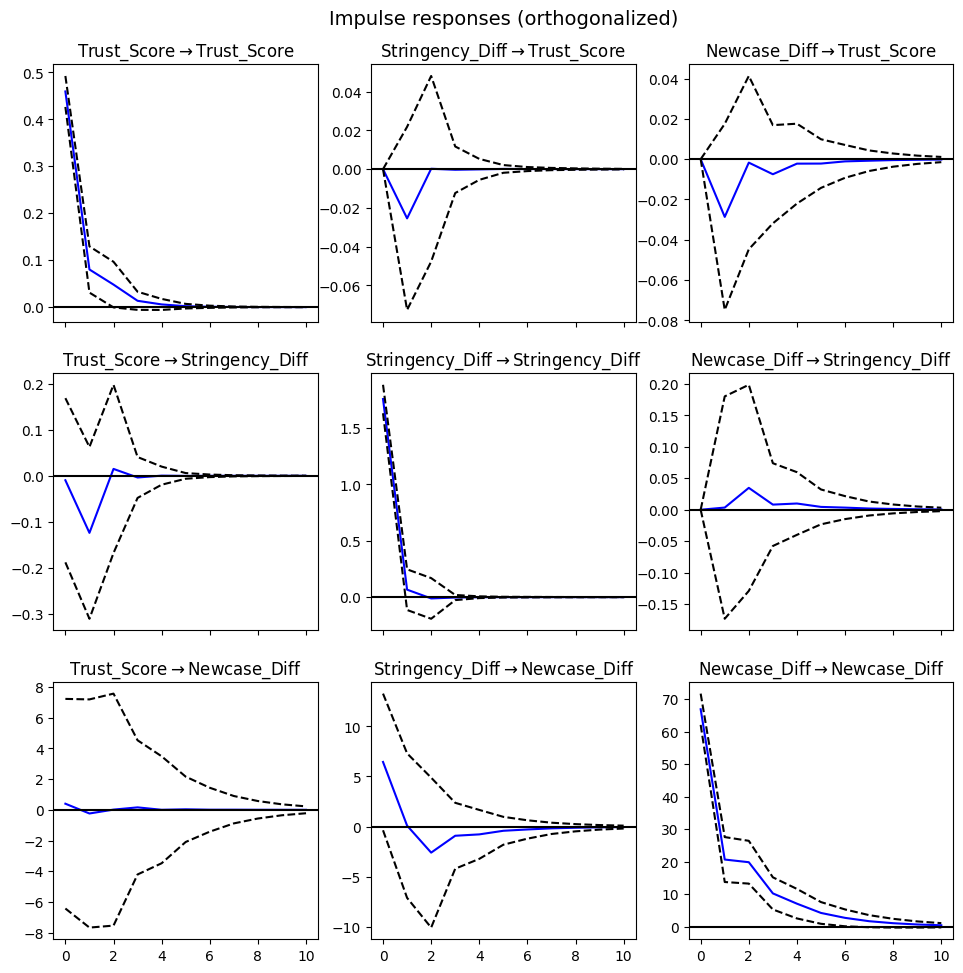

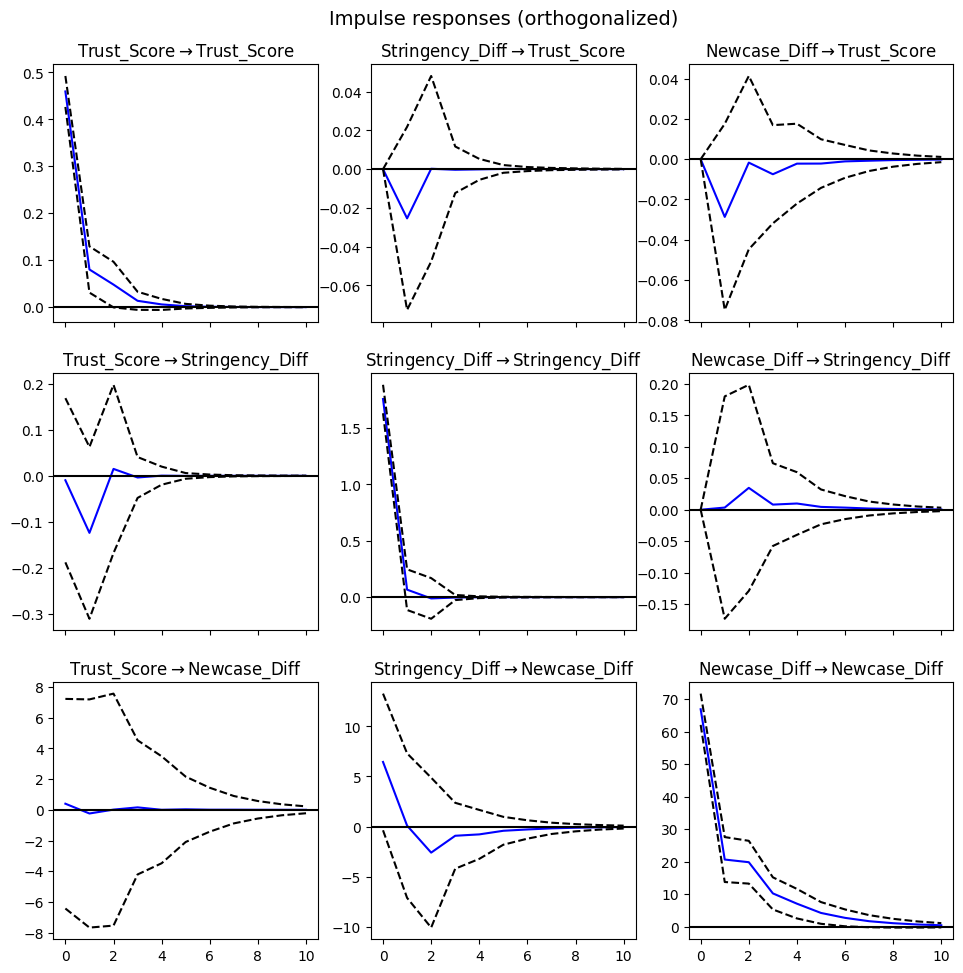

In [9]:
irf = results.irf(10)
irf.plot(orth=True)

Conclusion: IRF shows a dynamic sequence in which worsening pandemic conditions trigger stricter government policy, and stricter policy subsequently helps reduce new cases. However, both pandemic deterioration and policy tightening are associated with short-run declines in public trust. This suggests that policy response is effective epidemiologically, but may come with short-term public confidence costs.

VAR-Trust/Stringency/New_case

In [10]:
VAR_TSD = data_diff[['Trust_Score', 'Stringency_Diff', 'Death_Diff']]
model = VAR(VAR_TSD)
results = model.fit(2)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 02, Apr, 2026
Time:                     22:50:32
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -1.76281
Nobs:                     372.000    HQIC:                  -1.89618
Log likelihood:          -1193.51    FPE:                   0.137515
AIC:                     -1.98403    Det(Omega_mle):        0.130036
--------------------------------------------------------------------
Results for equation Trust_Score
                        coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------
const                     -0.156221         0.026937           -5.799           0.000
L1.Trust_Score             0.149291         0.053878            2.771           0.006
L1.Stringency_Diff        -0.01191

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


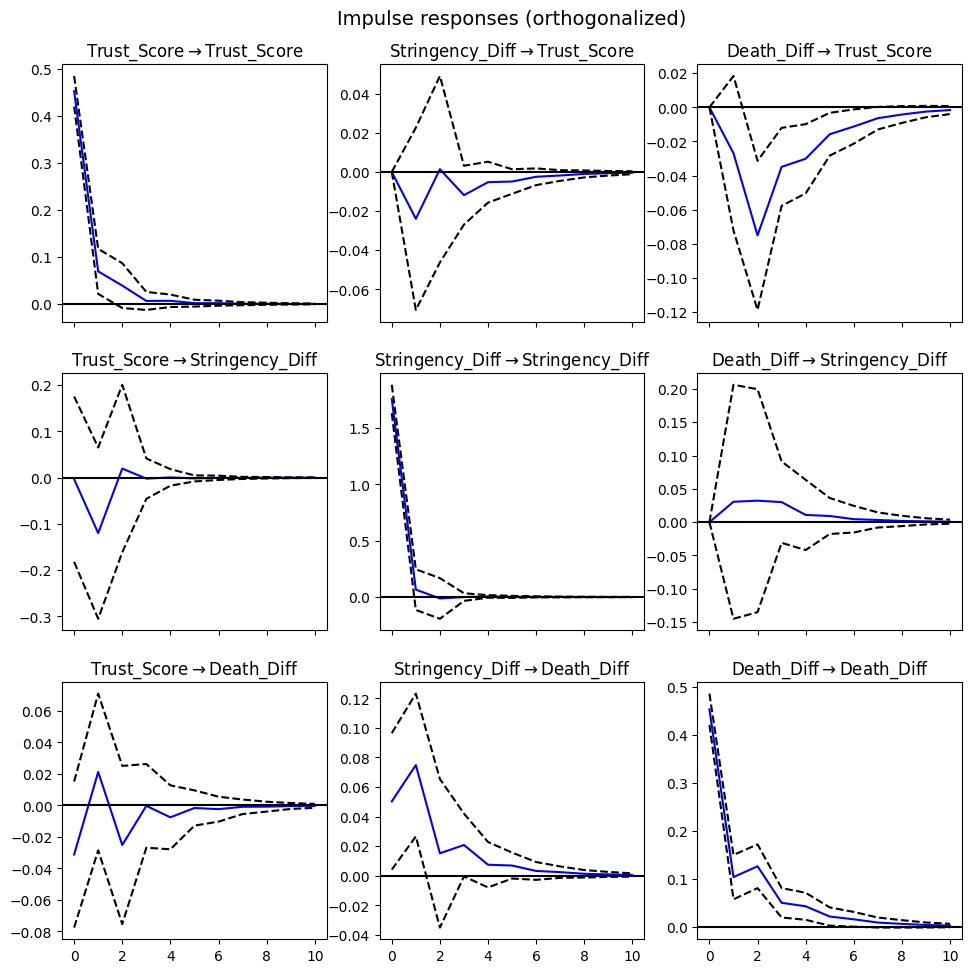

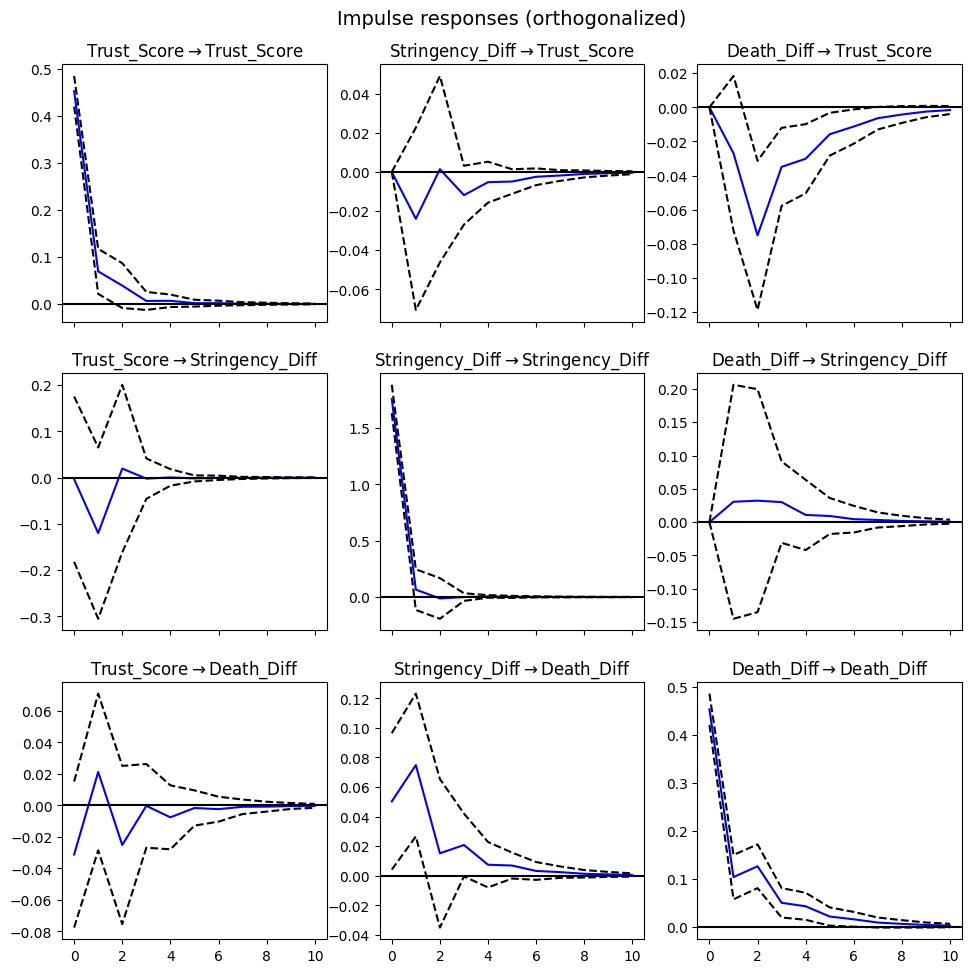

In [11]:
irf = results.irf(10)
irf.plot(orth=True)

Conclusion : The IRF results indicate that increases in deaths trigger stronger policy responses, reflecting government reaction to severe pandemic conditions. However, both rising deaths and policy tightening are associated with short-run declines in public trust. This suggests that trust is negatively affected by both outcome shocks and policy interventions.

# GAP MOUDULE

先用 VAR/IRF 看 policy、trust 和 pandemic outcomes 之间的动态互动机制。结果表明，疫情恶化会引发更强的政策反应，而政策收紧和疫情恶化都会在短期内压低公众信任。也就是说，这几个变量的调整并不是同步的。

既然 policy 和 trust 的动态反应不同步，那么下一个自然问题就是：这种不同步是否会累积成一个可量化的 policy–trust mismatch？为此，我进一步构造了 gap 指标，去衡量政策实施与公众感知之间的脱节程度。

First, we use VAR/IRF to examine the dynamic interaction mechanisms among policy, trust, and pandemic outcomes. The results indicate that a worsening pandemic triggers a stronger policy response, while both policy tightening and a worsening pandemic reduce public trust in the short term. In other words, adjustments in these variables are not synchronized.

Given that the dynamic responses of policy and trust are not synchronized, the next natural question is: Does this asynchrony accumulate into a quantifiable policy–trust mismatch? To address this, I further constructed a gap indicator to measure the degree of disconnect between policy implementation and public perception.

GAP Construction and policy lag effect

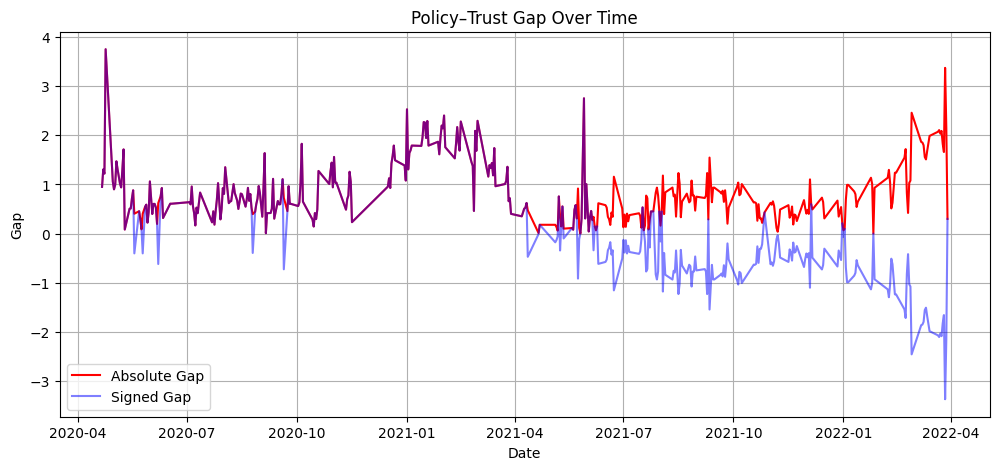

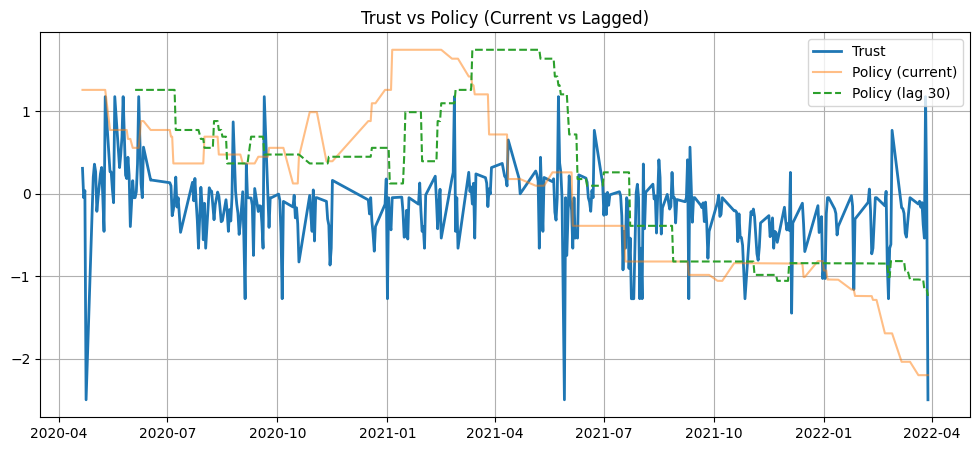

In [12]:
# counstruction of absolute GAP and signed GAP 
gap_df = construction_gap("processed_data.csv")
plt.figure(figsize=(12,5))
plt.plot(gap_df.index, gap_df['Gap_abs'], label='Absolute Gap', color='red')
plt.plot(gap_df.index, gap_df['Gap_signed'], label='Signed Gap', color='blue', alpha=0.5)
plt.title('Policy–Trust Gap Over Time')
plt.xlabel('Date')
plt.ylabel('Gap')
plt.legend()
plt.grid(True)
plt.show()

# regression analysis of the relationship between policy change and absolute gap
lag_value = 30
df_var = gap_var("processed_data.csv",lags=lag_value)
plt.figure(figsize=(12,5))
plt.plot(df_var.index, df_var['Trust_Score'], label='Trust', linewidth=2)
plt.plot(df_var.index, df_var['Stringency_z'], label='Policy (current)', alpha=0.5)
plt.plot(df_var.index, df_var['Stringency_lag' + str(lag_value)], label='Policy (lag ' + str(lag_value) + ')', linestyle='--')
plt.title('Trust vs Policy (Current vs Lagged)')
plt.legend()
plt.grid(True)

plt.show()

Conclusion:   
Just approved that:  
Trust_t ≈ Policy (lag)
That is:  
Trust_t ≈ Policy _(t−25)
Therefore:  
Gap_t​=Policy_t​−Trust_t​≈Policy_t​−Policy_t−25​  

Policy change (Δ policy) and gap relations

In [13]:
# regression analysis
reg_df = build_reg_df("processed_data.csv", 
             gap_df, 
             stringency_lag=lag_value, policy_change_lag=lag_value,
             trust_lag=1, cases_lag=7, death_lag=1,)
reg_df.columns

Index(['Trust_Score', 'Stringency_z', 'Newcase_z', 'Death_z', 'Stringency_lag',
       'Trust_lag', 'Cases_lag', 'Death_lag', 'Policy_change', 'Gap_signed',
       'Gap_abs'],
      dtype='str')

In [14]:
x = sm.add_constant(reg_df['Policy_change'])
y = reg_df['Gap_abs']
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Gap_abs   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     51.26
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           4.95e-12
Time:                        22:50:34   Log-Likelihood:                -281.42
No. Observations:                 345   AIC:                             566.8
Df Residuals:                     343   BIC:                             574.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.9157      0.032     28.795

In [15]:
X = sm.add_constant(reg_df[['Policy_change', 'Trust_lag', 'Cases_lag', 'Death_lag']])
y = reg_df['Gap_abs']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Gap_abs   R-squared:                       0.366
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     48.99
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.59e-32
Time:                        22:50:34   Log-Likelihood:                -226.95
No. Observations:                 345   AIC:                             463.9
Df Residuals:                     340   BIC:                             483.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.8806      0.031     28.096

In [16]:
print(reg_df['Death_lag'].corr(reg_df['Trust_Score']))
print(reg_df['Death_lag'].corr(reg_df['Stringency_z']))

-0.041201467042306185
0.49017106007810657


Conclustion:   
The gap exists and has widened significantly in recent months.  
The gap is primarily driven by the severity of the pandemic.  
The gap stems from rapid policy adjustments, while public trust lags behind these changes.  

The gap stems from rapid policy adjustments, while public trust lags behind these adjustments
My gap analysis demonstrates that the relationship between policy and trust exhibits distinct characteristics of dynamic mismatch. As the pandemic worsens, the government rapidly tightens policy measures, but public trust does not adjust in tandem, causing the policy–trust gap to widen. In other words, my research does not simply examine the correlation between policy and trust, but rather investigates the mismatch and temporal misalignment between the two

Signal to adjust policy pace

In [17]:
#introduce variables
y = reg_df['Gap_abs']
features = [
    'Death_lag',
    'Cases_lag',
    'Policy_change',
    'Trust_lag'
]
X = reg_df[features]
df_ml = pd.concat([X, y], axis=1).dropna()
X = df_ml[features]
y = df_ml['Gap_abs']
df_ml = df_ml.sort_index()
#split data into train and test sets
split = int(len(df_ml) * 0.8)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]


In [18]:
#random forest regression
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_lr, "Linear Regression")
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

Random Forest RMSE: 0.8582329261946118
Random Forest R2: -0.5572469956350685
------
Linear Regression RMSE: 0.9556698129760498
Linear Regression R2: -0.9309138302519968
------
Policy_change    0.554719
Death_lag        0.242219
Trust_lag        0.107815
Cases_lag        0.095247
dtype: float64


Conclusion: In the gap module, the OLS results discussed earlier indicate that the death shock widens the policy–trust gap by driving an increase in the policy response. However, machine learning analysis further reveals that policy adjustment is the most critical variable in predicting the severity of the mismatch, with its importance even surpassing that of death itself.  

This suggests that the shock itself is not sufficient to determine the widening of the mismatch; what truly matters is the intensity and speed of the government’s policy response to the shock. Therefore, from a policy perspective, rather than focusing solely on the deterioration of outcomes, it is better to manage policy adjustments more cautiously to avoid amplifying the policy–trust gap.